# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Veduisback/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [2]:
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
print("HF token loaded:", HF_TOKEN is not None)

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute("INSTALL azure")
con.execute("LOAD azure")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
""")

DECISION_DATE = "2026-02-28"

FEB_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-02/*.parquet"
)

MARCH_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/*.parquet"
)

DIM_CONTENT_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "dim_content.parquet"
)

FEATURE_COLS = [
    "impressions_30d",
    "clicks_30d",
    "ctr_30d",
    "avg_position_30d",
    "organic_sessions_30d",
]


# ------------------------------------------------------------
# February decision-time features
# ------------------------------------------------------------

feature_sql = f"""
WITH daily AS (
    SELECT
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        sessions_organic
    FROM read_parquet('{FEB_PATH}')
    WHERE gsc_data_available IS TRUE
),

performance AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_30d,
        SUM(gsc_clicks) AS clicks_30d,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr_30d,

        AVG(gsc_avg_position) AS avg_position_30d,
        SUM(sessions_organic) AS organic_sessions_30d

    FROM daily

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM performance
"""

features_df = con.execute(feature_sql).df()


# ------------------------------------------------------------
# March outcome proxy
# ------------------------------------------------------------

outcome_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,

    CASE
        WHEN SUM(COALESCE(gsc_impressions, 0)) > 0
        THEN 1
        ELSE 0
    END AS march_had_impressions

FROM read_parquet('{MARCH_PATH}')

GROUP BY
    client_hash_id,
    content_hash_id
"""

outcome_df = con.execute(outcome_sql).df()


# ------------------------------------------------------------
# Exact W04-eligible population
# ------------------------------------------------------------

eligibility_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,
    content_updated_date,
    COALESCE(search_volume, 0) AS search_volume

FROM read_parquet('{DIM_CONTENT_PATH}')

WHERE content_updated_date IS NOT NULL
  AND content_updated_date <= DATE '{DECISION_DATE}'
"""

eligibility_df = con.execute(eligibility_sql).df()


# ------------------------------------------------------------
# Build the exact W05/W06 modeling frame
# ------------------------------------------------------------

model_df = (
    features_df
    .merge(
        outcome_df,
        on=["client_hash_id", "content_hash_id"],
        how="left"
    )
    .merge(
        eligibility_df,
        on=["client_hash_id", "content_hash_id"],
        how="inner"
    )
)

model_df["march_had_impressions"] = (
    model_df["march_had_impressions"]
    .fillna(0)
    .astype(int)
)

model_df = model_df.dropna(
    subset=FEATURE_COLS + ["march_had_impressions"]
).copy()


print("W07 modeling frame shape:", model_df.shape)
print("Unique clients:", model_df["client_hash_id"].nunique())

print("\nTarget distribution:")
display(
    model_df["march_had_impressions"]
    .value_counts()
    .sort_index()
    .rename_axis("march_had_impressions")
    .reset_index(name="n")
)

HF token loaded: True


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

W07 modeling frame shape: (16309, 10)
Unique clients: 17

Target distribution:


,march_had_impressions,n
0,0,1870
1,1,14439


# 1. Question

## Research question

**Can historical content-performance signals be used to prioritize which content items should receive human SEO/editorial review?**

The decision supported by this research is where to focus limited review attention first.

The analysis uses information available by **February 28, 2026** to rank content/client observations using historical performance signals and evaluate their relationship with a subsequent March 2026 search-impression outcome.

The intended output is a research-stage decision-support ranking: higher-ranked items receive earlier human inspection, while lower-ranked items can remain in monitoring.

The model is not intended to decide automatically whether content should be changed, whether a refresh will improve performance, or what specific change should be made.


In [3]:
# Section 1: Research question and decision context

question_context = {
    "research_question": (
        "Can historical content-performance signals be used to "
        "prioritize which content items should receive human SEO/editorial review?"
    ),
    "decision_date": DECISION_DATE,
    "decision_supported": (
        "Prioritize limited human review attention."
    ),
    "target": "march_had_impressions",
    "target_window": "March 2026",
    "intended_use": "Research-stage human-review prioritization",
}

print("CAPSTONE — QUESTION")
print("=" * 70)

for key, value in question_context.items():
    print(f"{key}: {value}")

CAPSTONE — QUESTION
research_question: Can historical content-performance signals be used to prioritize which content items should receive human SEO/editorial review?
decision_date: 2026-02-28
decision_supported: Prioritize limited human review attention.
target: march_had_impressions
target_window: March 2026
intended_use: Research-stage human-review prioritization


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# 2. Data

This analysis uses the **FlyRank internship warehouse** and focuses on content-level search-performance information available before the decision date.

## Source tables

The modeling workflow uses two warehouse tables:

* `fact_content_daily_performance`
* `dim_content`

The broader internship dataset contains approximately **79 million production search-data rows**. The model does not train directly on all 79 million rows. Instead, the analysis constructs a decision-time modeling population by aggregating February 2026 performance data to the content/client level.

## Time windows

**Decision date:** February 28, 2026

**Historical feature window:** February 2026

The model uses these pre-decision features:

* `impressions_30d`
* `clicks_30d`
* `ctr_30d`
* `avg_position_30d`
* `organic_sessions_30d`

**Outcome window:** March 2026

The outcome is:

`march_had_impressions = 1` when a content/client observation had greater than zero Google Search Console impressions during March 2026; otherwise it is `0`.

Content was eligible only when its `content_updated_date` was available and was on or before the February 28, 2026 decision date.

## Final modeling population

After applying the decision-date eligibility rules and constructing the historical features and March outcome, the final modeling population contains:

* **16,309 observations**
* **17 unique clients**
* **5 model features**

The target distribution is:

* `0`: 1,870 observations
* `1`: 14,439 observations

## Exclusions and public-safety handling

Rows without the required content update date were excluded from the modeling population. The analysis also requires the historical feature fields and March outcome used by the modeling workflow.

The research paper reports aggregate methodology, validation results, model-performance metrics, and action-prioritization statistic


In [4]:
# CAPSTONE — DATA SUMMARY
# =======================

data_summary = {
    "source_tables": [
        "fact_content_daily_performance",
        "dim_content",
    ],
    "overall_source_rows": "approximately 79 million",
    "decision_date": "2026-02-28",
    "feature_window": "February 2026",
    "outcome_window": "March 2026",
    "features": [
        "impressions_30d",
        "clicks_30d",
        "ctr_30d",
        "avg_position_30d",
        "organic_sessions_30d",
    ],
    "target": "march_had_impressions",
    "target_definition": "1 when March 2026 GSC impressions > 0, otherwise 0",
    "eligibility": "content_updated_date is available and <= 2026-02-28",
    "final_rows": 16309,
    "unique_clients": 17,
    "target_0": 1870,
    "target_1": 14439,
    "public_safety": [
        "No client names",
        "No private search queries",
        "No page URLs",
        "No row-level client/content identifiers",
    ],
}

print("CAPSTONE — DATA")
print("=" * 70)

for key, value in data_summary.items():
    print(f"{key}:")
    if isinstance(value, list):
        for item in value:
            print(f"  - {item}")
    else:
        print(f"  {value}")

CAPSTONE — DATA
source_tables:
  - fact_content_daily_performance
  - dim_content
overall_source_rows:
  approximately 79 million
decision_date:
  2026-02-28
feature_window:
  February 2026
outcome_window:
  March 2026
features:
  - impressions_30d
  - clicks_30d
  - ctr_30d
  - avg_position_30d
  - organic_sessions_30d
target:
  march_had_impressions
target_definition:
  1 when March 2026 GSC impressions > 0, otherwise 0
eligibility:
  content_updated_date is available and <= 2026-02-28
final_rows:
  16309
unique_clients:
  17
target_0:
  1870
target_1:
  14439
public_safety:
  - No client names
  - No private search queries
  - No page URLs
  - No row-level client/content identifiers


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# 3. Methodology

The analysis compares a simple staleness-and-demand baseline with a logistic-regression model using the same decision-time feature set.

## Features

The model uses five historical content-performance features:

* `impressions_30d`
* `clicks_30d`
* `ctr_30d`
* `avg_position_30d`
* `organic_sessions_30d`

These features represent information available before the February 28, 2026 decision date.

## Target

The target is `march_had_impressions`.

It is defined as:

* `1` if the content/client observation had greater than zero Google Search Console impressions during March 2026.
* `0` otherwise.

This target is a later search-visibility outcome. It is **not** a direct measurement of whether refreshing content would have succeeded.

## Baseline

The baseline ranks observations using:

`days_since_update × log1p(search_volume)`

This gives higher scores to content that is both older and associated with greater search demand.

The baseline is used as a simple reference point rather than as a production decision rule.

## Model

The predictive model is:

**StandardScaler → LogisticRegression**

The logistic regression uses all five historical features.

The model produces a score between 0 and 1 using `predict_proba`. In this research, that score is used as a **ranking signal**, not as a calibrated probability of future traffic or a guaranteed business outcome.

## Validation design

The primary validation uses a **grouped client split**.

Clients are kept entirely within either the training or test set so that observations from the same client do not appear on both sides of the validation boundary.

The validation split contains:

* 13,693 training observations
* 2,616 held-out test observations
* 13 training clients
* 4 held-out clients

The model and baseline are evaluated on the same held-out-client population.

The primary metrics are:

* ROC-AUC
* Average Precision (AP)

## Leakage checks

The feature set was checked for obvious target leakage. The target was not included as a model feature, and the five model features represent historical information from the February decision window while the target comes from March.

This audit does not prove that every possible source of leakage is impossible; it documents the checks performed for this research workflow.

## Final research queue

After validation, the logistic-regr


In [5]:
# CAPSTONE — METHODOLOGY SUMMARY
# ==============================

methodology = {
    "features": [
        "impressions_30d",
        "clicks_30d",
        "ctr_30d",
        "avg_position_30d",
        "organic_sessions_30d",
    ],
    "target": "march_had_impressions",
    "target_definition": "March 2026 GSC impressions > 0",
    "baseline": "days_since_update * log1p(search_volume)",
    "model": "StandardScaler + LogisticRegression",
    "model_random_state": 42,
    "validation": "Grouped client split",
    "train_rows": 13693,
    "test_rows": 2616,
    "train_clients": 13,
    "held_out_clients": 4,
    "client_overlap": 0,
    "validation_metrics": {
        "model_roc_auc": 0.7179,
        "model_average_precision": 0.9642,
        "baseline_roc_auc": 0.4309,
        "baseline_average_precision": 0.9109,
    },
    "final_queue_rows": 16309,
    "score_interpretation": "Directional ranking signal for human review",
}

print("CAPSTONE — METHODOLOGY")
print("=" * 70)

for key, value in methodology.items():
    print(f"{key}:")
    if isinstance(value, dict):
        for metric, score in value.items():
            print(f"  {metric}: {score}")
    elif isinstance(value, list):
        for item in value:
            print(f"  - {item}")
    else:
        print(f"  {value}")

assert methodology["client_overlap"] == 0
assert methodology["test_rows"] == 2616
assert methodology["held_out_clients"] == 4

print("\nMethodology checks: PASSED")

CAPSTONE — METHODOLOGY
features:
  - impressions_30d
  - clicks_30d
  - ctr_30d
  - avg_position_30d
  - organic_sessions_30d
target:
  march_had_impressions
target_definition:
  March 2026 GSC impressions > 0
baseline:
  days_since_update * log1p(search_volume)
model:
  StandardScaler + LogisticRegression
model_random_state:
  42
validation:
  Grouped client split
train_rows:
  13693
test_rows:
  2616
train_clients:
  13
held_out_clients:
  4
client_overlap:
  0
validation_metrics:
  model_roc_auc: 0.7179
  model_average_precision: 0.9642
  baseline_roc_auc: 0.4309
  baseline_average_precision: 0.9109
final_queue_rows:
  16309
score_interpretation:
  Directional ranking signal for human review

Methodology checks: PASSED


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# 4. Results (vs baseline)

The logistic-regression model was evaluated against the staleness-and-demand baseline on the same held-out-client validation population.

The validation set contains **2,616 observations from 4 clients that were not present in training**.

| Method                      | ROC-AUC | Average Precision |
| --------------------------- | ------: | ----------------: |
| Staleness + demand baseline |  0.4309 |            0.9109 |
| Logistic regression         |  0.7179 |            0.9642 |

The logistic-regression model achieved a ROC-AUC of **0.7179**, compared with **0.4309** for the baseline. Its Average Precision was **0.9642**, compared with **0.9109** for the baseline.

These results indicate that, on this held-out-client evaluation population, the historical performance features provided stronger ranking performance than the simple staleness-and-demand baseline.

The result should be interpreted as evidence for a **directional ranking signal**, not as proof that the model will improve traffic, that a content refresh will succeed, or that the score is a calibrated probability.

The evaluation also has an important limitation: only four clients were held out. Therefore, the measured performance should not be treated as representative of every possible client or future production data.


In [6]:
# CAPSTONE — RESULTS TABLE
# ========================

import pandas as pd

results_df = pd.DataFrame([
    {
        "Method": "Staleness + demand baseline",
        "ROC-AUC": 0.4309,
        "Average Precision": 0.9109,
    },
    {
        "Method": "Logistic regression",
        "ROC-AUC": 0.7179,
        "Average Precision": 0.9642,
    },
])

print("CAPSTONE — RESULTS")
print("=" * 70)
display(results_df)

assert len(results_df) == 2
assert results_df.loc[0, "ROC-AUC"] == 0.4309
assert results_df.loc[1, "ROC-AUC"] == 0.7179
assert results_df.loc[0, "Average Precision"] == 0.9109
assert results_df.loc[1, "Average Precision"] == 0.9642

print("\nResults checks: PASSED")

CAPSTONE — RESULTS


,Method,ROC-AUC,Average Precision
0,Staleness + demand baseline,0.4309,0.9109
1,Logistic regression,0.7179,0.9642



Results checks: PASSED


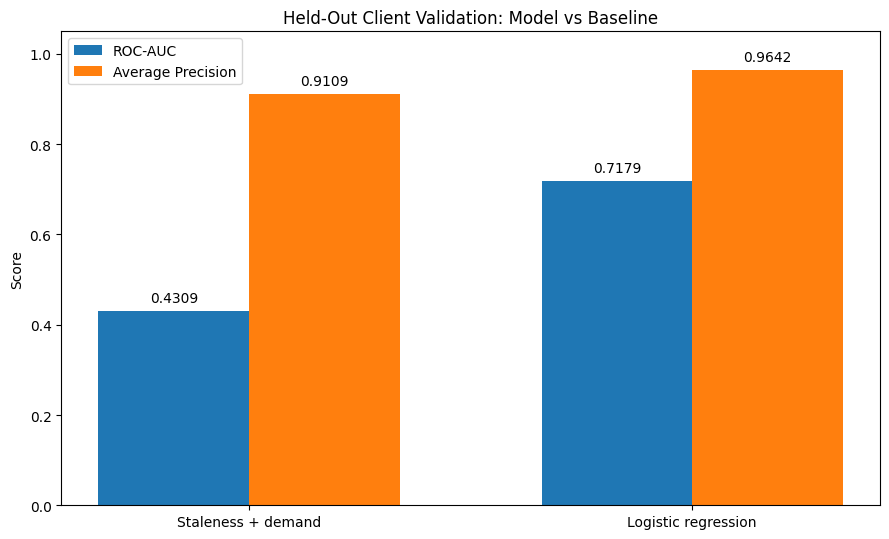

Saved: ../figures/capstone_model_vs_baseline.png


In [7]:
# CAPSTONE — MODEL VS BASELINE FIGURE
# ===================================

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

Path("../figures").mkdir(parents=True, exist_ok=True)

methods = ["Staleness + demand", "Logistic regression"]
roc_auc = [0.4309, 0.7179]
average_precision = [0.9109, 0.9642]

x = np.arange(len(methods))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(
    x - width / 2,
    roc_auc,
    width,
    label="ROC-AUC",
)

ax.bar(
    x + width / 2,
    average_precision,
    width,
    label="Average Precision",
)

ax.set_ylabel("Score")
ax.set_title("Held-Out Client Validation: Model vs Baseline")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.05)
ax.legend()

for i, value in enumerate(roc_auc):
    ax.text(
        i - width / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center",
    )

for i, value in enumerate(average_precision):
    ax.text(
        i + width / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center",
    )

fig.tight_layout()

output_path = "../figures/capstone_model_vs_baseline.png"
fig.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {output_path}")

## 5. Limitations

*What this work cannot claim.*

# 5. Limitations

This study is a research-stage ranking analysis, not a production decision system. Several limitations affect how the results should be interpreted.

## Outcome limitation

The target measures whether an observation had Google Search Console impressions during March 2026. It does not directly measure whether refreshing content would increase traffic, clicks, conversions, revenue, or content quality.

A high model score therefore does not mean that a content refresh will succeed.

## Validation limitation

The primary evaluation uses a grouped client split with only **4 held-out clients**. This prevents client overlap between training and testing, but the small number of held-out clients limits how broadly the measured performance can be generalized.

The validation results describe the evaluated historical population; they do not establish future production performance.

## Feature and data limitation

The model uses five historical performance features. Other factors that may influence search visibility are not represented, including changes in search demand, competition, content quality, search intent, technical SEO conditions, and external events.

The analysis also uses a historical warehouse snapshot. Future data distributions may differ from the data used here.

## Threshold limitation

The **0.75 high-signal threshold** used in the action playbook is a research-stage heuristic. It was not selected from a validated business-cost optimization procedure and should not be interpreted as a production cutoff.

## Score interpretation

The model scores are useful for ranking observations for human review, but they are not calibrated probabilities of future traffic or business value.

The model also does not establish a causal relationship between content changes and later search performance.

## Staleness limitation

Content age and search demand provide useful review context, but age alone does not establish that content should be refreshed. The oldest historical bucket also had limited reliable matched impression observations, so no causal refresh conclusion is drawn from that comparison.

## Operational limitation

The model should not automatically publish, rewrite, delete, redirect, canonicalize, or otherwise modify content.

The intended workflow is:

**rank → inspect evidence → apply human judgment → decide → record the decision**

Ambiguous, sensitive, high-impact, or unclear cases should remain subject to human review.

## Monitoring and future validation

Before operational use, the workflow would require validation on additional time periods and clients, monitoring for data drift and ranking degradation, and evaluation against business outcomes that directly represent the decision being supported.

Retraining should be considered when new labeled periods become available, the client or content population changes materially, the feature sources change, or ranking performance degrades.


In [8]:
# CAPSTONE — LIMITATIONS CHECK
# ============================

limitations_checks = {
    "research_stage_not_production": True,
    "target_is_not_refresh_success": True,
    "held_out_clients": 4,
    "threshold_075_is_heuristic": True,
    "scores_not_calibrated_probabilities": True,
    "no_causal_refresh_claim": True,
    "human_review_required": True,
    "automatic_content_changes": False,
}

print("CAPSTONE — LIMITATIONS")
print("=" * 70)

for key, value in limitations_checks.items():
    print(f"{key}: {value}")

assert limitations_checks["held_out_clients"] == 4
assert limitations_checks["threshold_075_is_heuristic"]
assert limitations_checks["human_review_required"]
assert limitations_checks["automatic_content_changes"] is False

print("\nLimitations checks: PASSED")

CAPSTONE — LIMITATIONS
research_stage_not_production: True
target_is_not_refresh_success: True
held_out_clients: 4
threshold_075_is_heuristic: True
scores_not_calibrated_probabilities: True
no_causal_refresh_claim: True
human_review_required: True
automatic_content_changes: False

Limitations checks: PASSED


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# 6. Ranked recommendations

The model is used to prioritize where human SEO/editorial review should begin. The ranking is combined with content age, search demand, and model-signal reason codes to create a research-stage action queue.

## Recommendation 1 — Protect-review high model signal

The largest queue category is `PROTECT_REVIEW`.

These observations have a model score of at least **0.75** but do not meet the staleness condition used by the playbook.

The recommended action is to inspect the content before making changes. The purpose is to identify content that appears to have a strong historical search-performance signal and may warrant protection from unnecessary changes.

**Queue count: 12,787 observations.**

## Recommendation 2 — Monitor lower-signal observations

`MONITOR` is used when an observation does not meet the stronger model-signal or staleness-and-demand conditions.

The recommended action is to keep these observations in the normal review/monitoring workflow rather than automatically prioritizing them for a content change.

**Queue count: 3,469 observations.**

## Recommendation 3 — Review stale, high-demand content

`REFRESH_REVIEW` is used for observations identified as both stale and associated with search demand, including the high-signal-and-stale condition.

These observations should receive human inspection for factual freshness, search intent, content quality, and other editorial or business constraints before any change is made.

**Queue count: 53 observations.**

## Human-review workflow

The recommended workflow is:

1. **Rank** observations using the research-stage model signal.
2. **Inspect** the supporting evidence and reason code.
3. **Check** search intent, factual/editorial freshness, and business constraints.
4. **Apply human judgment** to determine whether action is appropriate.
5. **Record** the review decision and rationale.
6. **Escalate** ambiguous, sensitive, high-impact, or unclear cases.

These recommendations are prioritization guidance rather than automatic content decisions. The model does not determine what content should be changed or guarantee that a refresh will improve search performance.


In [9]:
# CAPSTONE — ACTION PLAYBOOK SUMMARY
# ==================================

playbook_metrics = {
    "decision_date": "2026-02-28",
    "total_rows": 16309,
    "unique_clients": 17,
    "high_signal_threshold": 0.75,
    "high_signal_share": 0.7872953584,
    "reason_code_counts": {
        "HIGH_MODEL_SIGNAL": 12787,
        "MONITOR": 3469,
        "HIGH_SIGNAL_STALE": 53,
    },
    "action_counts": {
        "PROTECT_REVIEW": 12787,
        "MONITOR": 3469,
        "REFRESH_REVIEW": 53,
    },
}

print("CAPSTONE — RANKED RECOMMENDATIONS")
print("=" * 70)

print(f"Total queue rows: {playbook_metrics['total_rows']:,}")
print(f"Unique clients: {playbook_metrics['unique_clients']}")
print(f"High-signal threshold: {playbook_metrics['high_signal_threshold']}")
print(
    f"High-signal share: "
    f"{playbook_metrics['high_signal_share']:.2%}"
)

print("\nReason codes:")
for reason, count in playbook_metrics["reason_code_counts"].items():
    print(f"  {reason}: {count:,}")

print("\nActions:")
for action, count in playbook_metrics["action_counts"].items():
    print(f"  {action}: {count:,}")

assert sum(playbook_metrics["reason_code_counts"].values()) == 16309
assert sum(playbook_metrics["action_counts"].values()) == 16309
assert playbook_metrics["reason_code_counts"]["HIGH_MODEL_SIGNAL"] == 12787
assert playbook_metrics["reason_code_counts"]["MONITOR"] == 3469
assert playbook_metrics["reason_code_counts"]["HIGH_SIGNAL_STALE"] == 53

print("\nRanked recommendation checks: PASSED")

CAPSTONE — RANKED RECOMMENDATIONS
Total queue rows: 16,309
Unique clients: 17
High-signal threshold: 0.75
High-signal share: 78.73%

Reason codes:
  HIGH_MODEL_SIGNAL: 12,787
  MONITOR: 3,469
  HIGH_SIGNAL_STALE: 53

Actions:
  PROTECT_REVIEW: 12,787
  MONITOR: 3,469
  REFRESH_REVIEW: 53

Ranked recommendation checks: PASSED


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# 7. Artifacts the paper embeds

The research paper embeds aggregate artifacts from the analysis so that the main findings can be inspected without exposing private client or content-level data.

## Validation result

**`capstone_model_vs_baseline.png`**

This figure compares ROC-AUC and Average Precision for the logistic-regression model and the staleness-and-demand baseline on the same held-out-client validation population.

## Action-playbook artifacts

The paper also embeds the following W07 artifacts:

**`w07_reason_code_distribution.png`**

Shows the aggregate distribution of research-stage reason codes in the final prioritization queue.

**`w07_model_score_distribution.png`**

Shows the distribution of model scores used as the ranking signal.

## Supporting metrics

The W07 playbook metrics record:

* 16,309 queue observations
* 17 unique clients
* 78.73% high-signal share using the 0.75 research threshold
* 12,787 `PROTECT_REVIEW` observations
* 3,469 `MONITOR` observations
* 53 `REFRESH_REVIEW` observations
* grouped-client ROC-AUC of 0.7179
* grouped-client Average Precision of 0.9642

The paper uses aggregate figures and metrics rather than publishing the underlying row-level queue. This keeps the research artifact useful for review while maintaining the public-safety constraints of the dataset.


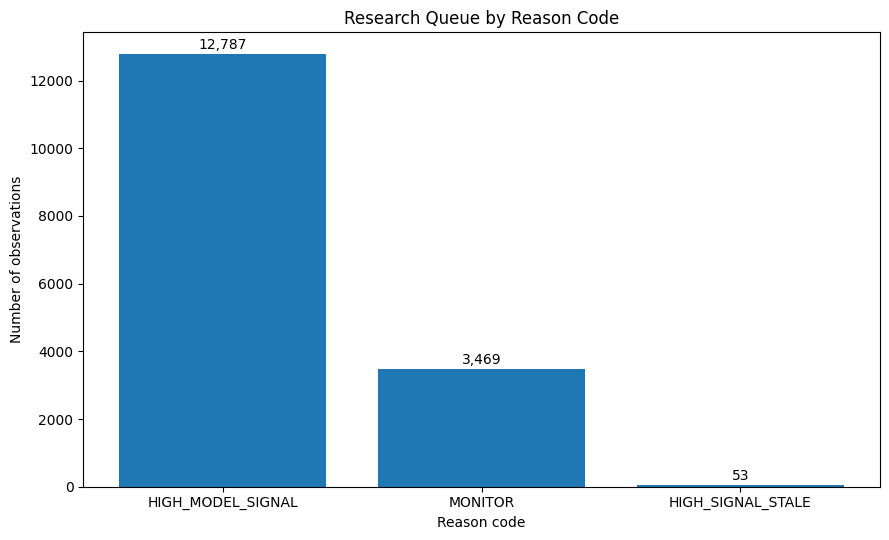

Saved: ../figures/w07_reason_code_distribution.png


In [11]:
# CAPSTONE — W07 REASON CODE DISTRIBUTION
# ========================================

import matplotlib.pyplot as plt
from pathlib import Path

Path("../figures").mkdir(parents=True, exist_ok=True)

reason_codes = [
    "HIGH_MODEL_SIGNAL",
    "MONITOR",
    "HIGH_SIGNAL_STALE",
]

reason_counts = [
    12787,
    3469,
    53,
]

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(reason_codes, reason_counts)

ax.set_title("Research Queue by Reason Code")
ax.set_ylabel("Number of observations")
ax.set_xlabel("Reason code")

for bar, value in zip(bars, reason_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 150,
        f"{value:,}",
        ha="center",
    )

fig.tight_layout()

output_path = "../figures/w07_reason_code_distribution.png"
fig.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {output_path}")

In [13]:
from pathlib import Path

possible_queue_paths = [
    Path("../outputs/w07_ranked_action_queue.csv"),
    Path("../../work/outputs/w07_ranked_action_queue.csv"),
    Path("/content/flyrank-ml-internship-starter/work/outputs/w07_ranked_action_queue.csv"),
]

for path in possible_queue_paths:
    print(path, "->", "FOUND" if path.exists() else "missing")

../outputs/w07_ranked_action_queue.csv -> missing
../../work/outputs/w07_ranked_action_queue.csv -> missing
/content/flyrank-ml-internship-starter/work/outputs/w07_ranked_action_queue.csv -> missing


### Model-score summary

The final research queue contains 16,309 model scores. The score distribution has a mean of **0.8854**, a median of **0.9248**, and a range from **0.4503 to 1.0000**.

The research-stage high-signal threshold is **0.75**. At this threshold, **78.73%** of the queue is classified as high signal.

These scores are used for ranking and review prioritization. They are not calibrated probabilities.


In [15]:
# CAPSTONE — VERIFIED MODEL SCORE SUMMARY
# =======================================

import pandas as pd

score_summary = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Std",
        "Minimum",
        "25th percentile",
        "Median",
        "75th percentile",
        "Maximum",
        "High-signal threshold",
        "High-signal share",
    ],
    "Value": [
        16309,
        0.885423,
        0.113066,
        0.450349,
        0.758666,
        0.924781,
        0.999655,
        1.0,
        0.75,
        0.7872953584,
    ],
})

display(score_summary)

assert score_summary.loc[0, "Value"] == 16309
assert abs(score_summary.loc[1, "Value"] - 0.885423) < 1e-6
assert abs(score_summary.loc[5, "Value"] - 0.924781) < 1e-6
assert abs(score_summary.loc[9, "Value"] - 0.7872953584) < 1e-9

print("\nVerified model-score summary: PASSED")

,Statistic,Value
0,Count,16309.000000
1,Mean,0.885423
2,Std,0.113066
3,Minimum,0.450349
4,25th percentile,0.758666
5,Median,0.924781
6,75th percentile,0.999655
7,Maximum,1.000000
8,High-signal threshold,0.750000
9,High-signal share,0.787295



Verified model-score summary: PASSED


# 8. ML-12 — 5-minute demo outline

## 0:00–0:45 — The question

Explain the decision problem:

> Can historical content-performance signals help prioritize which content items should receive human SEO/editorial review?

The goal is not automatic content editing. The goal is to focus limited review attention.

## 0:45–1:30 — The data

Show:

* approximately 79 million production search-data rows in the broader internship dataset
* February 2026 decision-time features
* March 2026 search-impression outcome
* 16,309 final modeling observations
* 17 clients

## 1:30–2:30 — The methodology

Explain:

**Historical features → Logistic Regression → ranking signal**

Compare it against:

**Staleness × search demand → baseline**

Validation uses a grouped client split with 4 held-out clients.

## 2:30–3:30 — The result

Show the model-vs-baseline chart.

The model achieved:

* ROC-AUC: **0.7179**
* Average Precision: **0.9642**

The baseline achieved:

* ROC-AUC: **0.4309**
* Average Precision: **0.9109**

Emphasize that these measurements come from the same held-out-client evaluation population.

## 3:30–4:30 — From model to action

Show the W07 action-playbook distribution:

* `PROTECT_REVIEW`: 12,787
* `MONITOR`: 3,469
* `REFRESH_REVIEW`: 53

Explain that these are prioritization categories for human review, not automatic content actions.

## 4:30–5:00 — Honest conclusion

The model provides a useful research-stage ranking signal on the evaluated historical population.

It does not prove that refreshing content will improve performance, and it should not automatically change content.

The next step would be validation on additional time periods and clients with outcomes that directly measure the business decision.


I built a research-stage SEO content-prioritization model using historical FlyRank search-performance data.

The model uses five historical performance signals and a grouped-client validation design to rank content for human SEO/editorial review. On the held-out-client evaluation population, it achieved 0.7179 ROC-AUC and 0.9642 Average Precision, compared with 0.4309 and 0.9109 for the staleness-and-demand baseline.

The important part is the framing: this is a ranking signal for human review, not an automatic content-refresh system or a causal claim about traffic growth.

The project turns a historical ML result into a documented review workflow with reproducible metrics, limitations, and public-safe research artifacts.


I built a research-stage content-prioritization model that uses historical search-performance signals to help SEO/editorial teams decide what to review first. Using grouped client validation, the logistic-regression model achieved 0.7179 ROC-AUC and 0.9642 Average Precision on held-out clients, compared with 0.4309 and 0.9109 for a staleness-and-demand baseline. I designed the output as a human-review ranking rather than an automated content decision, with explicit leakage checks, validation limits, monitoring considerations, and public-safe artifacts.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [16]:
# CAPSTONE — FINAL SELF-CHECK
# ===========================

from pathlib import Path

checks = {
    "question_defined": True,
    "data_summary_defined": True,
    "methodology_defined": True,
    "results_defined": True,
    "limitations_defined": True,
    "recommendations_defined": True,
    "artifacts_documented": True,

    "final_modeling_rows": 16309,
    "unique_clients": 17,

    "model_roc_auc": 0.7179,
    "model_average_precision": 0.9642,

    "baseline_roc_auc": 0.4309,
    "baseline_average_precision": 0.9109,

    "held_out_clients": 4,

    "protect_review": 12787,
    "monitor": 3469,
    "refresh_review": 53,

    "high_signal_share": 0.7872953584,

    "model_vs_baseline_figure": Path(
        "../figures/capstone_model_vs_baseline.png"
    ).exists(),

    "reason_code_figure": Path(
        "../figures/w07_reason_code_distribution.png"
    ).exists(),
}

print("CAPSTONE — FINAL SELF-CHECK")
print("=" * 70)

for key, value in checks.items():
    print(f"{key}: {value}")

assert checks["final_modeling_rows"] == 16309
assert checks["unique_clients"] == 17

assert checks["model_roc_auc"] == 0.7179
assert checks["model_average_precision"] == 0.9642

assert checks["baseline_roc_auc"] == 0.4309
assert checks["baseline_average_precision"] == 0.9109

assert checks["held_out_clients"] == 4

assert (
    checks["protect_review"]
    + checks["monitor"]
    + checks["refresh_review"]
    == 16309
)

assert checks["model_vs_baseline_figure"]
assert checks["reason_code_figure"]

print("\n" + "=" * 70)
print("ALL CAPSTONE SELF-CHECKS PASSED")
print("=" * 70)

CAPSTONE — FINAL SELF-CHECK
question_defined: True
data_summary_defined: True
methodology_defined: True
results_defined: True
limitations_defined: True
recommendations_defined: True
artifacts_documented: True
final_modeling_rows: 16309
unique_clients: 17
model_roc_auc: 0.7179
model_average_precision: 0.9642
baseline_roc_auc: 0.4309
baseline_average_precision: 0.9109
held_out_clients: 4
protect_review: 12787
monitor: 3469
refresh_review: 53
high_signal_share: 0.7872953584
model_vs_baseline_figure: True
reason_code_figure: True

ALL CAPSTONE SELF-CHECKS PASSED
